# Simpson's Rule (Single & Composite)
Straight lines (trapezoids) are okay, but curves are better. Simpson's rule draws parabolas through sets of 3 points to trace the top of the curve.
Because a parabola curves, it hugs the real mathematical function much tighter than a straight line, making this extremely accurate.

### The Math
For a single pair of panels from $a$ to $b$ with midpoint $m = \frac{a+b}{2}$ and width $h = \frac{b-a}{2}$, the area under the parabola is computed using weights $1, 4, 1$:
$$ \text{Area} = \frac{h}{3} (f(a) + 4f(m) + f(b)) $$

For the Composite Simpson's Rule with $m$ panels (where $m$ must be an even number), the weights overlap and follow a $1-4-2-4-2 \dots 4-1$ pattern:
$$ \int_a^b f(x) dx \approx \frac{h}{3} \left[ f(x_0) + 4 \sum_{\text{odd } i} f(x_i) + 2 \sum_{\text{even } i} f(x_i) + f(x_m) \right] $$

In [2]:
import numpy as np

def f(x):
    return x**2

def simpson_single(f, a, b):
    # A single application requires 3 points: the ends and the exact middle
    midpoint = (a + b) / 2
    h = (b - a) / 2
    
    # Formula uses weights: 1, 4, 1
    area = (h / 3) * (f(a) + 4*f(midpoint) + f(b))
    return area

def simpson_composite(f, a, b, num_panels):
    # Simpson's rule needs an EVEN number of panels
    if num_panels % 2 != 0:
        raise ValueError("Number of panels must be even for Simpson's Rule.")
        
    h = (b - a) / num_panels
    x = np.linspace(a, b, num_panels + 1)
    
    # Weights follow a pattern: 1, 4, 2, 4, 2, ... 4, 1
    y = f(x)
    area = (h / 3) * (y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-1:2]) + y[-1])
    return area

# Example usage
print("Single Simpson Area:", simpson_single(f, 0, 1))
print("Composite Simpson Area (100 panels):", simpson_composite(f, 0, 1, 100))


Single Simpson Area: 0.3333333333333333
Composite Simpson Area (100 panels): 0.33333333333333337


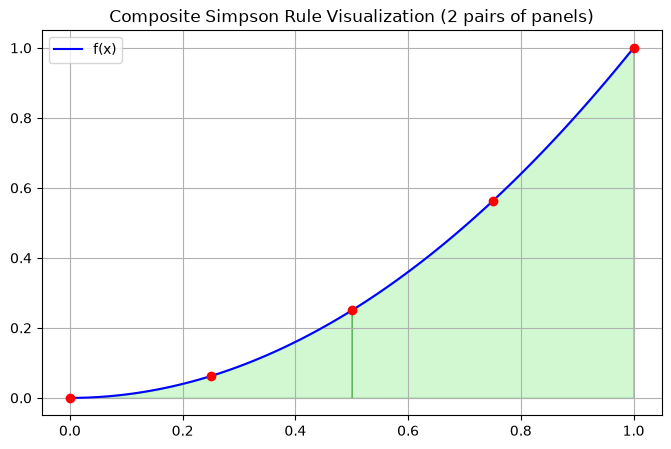

In [3]:
import matplotlib.pyplot as plt
import numpy as np
x_fine = np.linspace(0, 1, 100)
y_fine = f(x_fine)
x_simp = np.linspace(0, 1, 5)
y_simp = f(x_simp)
plt.figure(figsize=(8, 5))
plt.plot(x_fine, y_fine, 'b-', label='f(x)')
for i in range(0, 4, 2):
    xs = np.linspace(x_simp[i], x_simp[i+2], 50)
    coeffs = np.polyfit([x_simp[i], x_simp[i+1], x_simp[i+2]], [y_simp[i], y_simp[i+1], y_simp[i+2]], 2)
    ys = np.polyval(coeffs, xs)
    plt.fill_between(xs, 0, ys, color='lightgreen', alpha=0.4, edgecolor='g', linewidth=1)
plt.plot(x_simp, y_simp, 'ro', label='Nodes' if i==0 else '')
plt.title('Composite Simpson Rule Visualization (2 pairs of panels)')
plt.legend()
plt.grid(True)
plt.show()
